# Project Delay Correlation Analysis - All Customers

This notebook analyzes `custpaydetails_project_delay_correlates_allcustomers_hardcoded_keywords_2026-06-08-1224.csv`, the corrected project-level correlates dataset with hardcoded keyword predictors.

Primary target: `PERCENTDELAYED`.
Secondary targets: `ACTUALSTARTLAGDAYS` and `ACTUALENDLAGDAYS`.

Methods: Pearson, Spearman, and Kendall correlations. Spearman is used as the main ranking statistic because many predictors are skewed counts, dollar amounts, and keyword frequencies.

In [1]:
import csv, math, re, os
from pathlib import Path
from collections import Counter
import numpy as np
from scipy import stats
from IPython.display import display, HTML, SVG

DATA_FILE = Path('custpaydetails_project_delay_correlates_allcustomers_hardcoded_keywords_2026-06-08-1224.csv')
OUT_PREFIX = 'project_delay_correlation_analysis_allcustomers'
TARGETS = ['PERCENTDELAYED', 'ACTUALSTARTLAGDAYS', 'ACTUALENDLAGDAYS']

In [2]:
def esc(x):
    return str(x).replace('&','&amp;').replace('<','&lt;').replace('>','&gt;').replace('"','&quot;')

def fmt(x, d=4):
    if x is None: return ''
    try:
        xf=float(x)
    except Exception:
        return esc(x)
    if not math.isfinite(xf): return ''
    if abs(xf)>=1000: return f'{xf:,.2f}'
    if abs(xf)>=10: return f'{xf:,.2f}'
    return f'{xf:,.{d}f}'

def table(rows, cols=None, title=None, max_rows=30):
    rows=list(rows)
    if cols is None: cols=list(rows[0].keys()) if rows else []
    h=[]
    if title: h.append(f'<h3>{esc(title)}</h3>')
    h.append('<div style="overflow-x:auto"><table style="border-collapse:collapse;font-size:12px">')
    h.append('<tr>' + ''.join(f'<th style="border-bottom:1px solid #999;padding:4px 7px;text-align:left;white-space:nowrap">{esc(c)}</th>' for c in cols) + '</tr>')
    for r in rows[:max_rows]:
        h.append('<tr>')
        for c in cols:
            v=r.get(c,'')
            align='right' if isinstance(v,(int,float,np.integer,np.floating)) else 'left'
            h.append(f'<td style="border-bottom:1px solid #ddd;padding:3px 7px;text-align:{align};white-space:nowrap">{fmt(v)}</td>')
        h.append('</tr>')
    h.append('</table></div>')
    if len(rows)>max_rows: h.append(f'<p style="font-size:12px;color:#555">Showing {max_rows:,} of {len(rows):,} rows.</p>')
    return HTML('\\n'.join(h))

def write_csv(path, rows, cols=None):
    rows=list(rows)
    if cols is None: cols=list(rows[0].keys()) if rows else []
    with open(path,'w',newline='',encoding='utf-8') as f:
        w=csv.DictWriter(f, fieldnames=cols); w.writeheader()
        for r in rows: w.writerow({c:r.get(c,'') for c in cols})

def to_float(v):
    s=str(v).strip() if v is not None else ''
    if not s or s.upper() in {'NULL','NAN','NONE'}: return np.nan
    try: return float(s.replace(',',''))
    except Exception: return np.nan

def pct_summary(a):
    a=np.asarray(a,dtype=float); a=a[np.isfinite(a)]
    if len(a)==0: return {}
    qs=[0,1,5,10,25,50,75,90,95,99,100]
    out={'n':len(a),'mean':float(np.mean(a)),'std':float(np.std(a,ddof=1)) if len(a)>1 else 0.0}
    out.update({f'p{q}':float(v) for q,v in zip(qs,np.percentile(a,qs))})
    return out

def corr_pair(x,y,method):
    x=np.asarray(x,dtype=float); y=np.asarray(y,dtype=float)
    m=np.isfinite(x)&np.isfinite(y); x=x[m]; y=y[m]
    n=len(x)
    if n<5 or len(np.unique(x))<2 or len(np.unique(y))<2: return np.nan,np.nan,n
    try:
        if method=='pearson': r,p=stats.pearsonr(x,y)
        elif method=='spearman': r,p=stats.spearmanr(x,y)
        else: r,p=stats.kendalltau(x,y)
        return float(r),float(p),n
    except Exception:
        return np.nan,np.nan,n

def bh(pvals):
    p=np.array([float(x) if x is not None else np.nan for x in pvals],float)
    q=np.full_like(p,np.nan); idx=np.where(np.isfinite(p))[0]
    if len(idx)==0: return q
    order=idx[np.argsort(p[idx])]; vals=p[order]; m=len(vals); adj=np.empty(m); prev=1.0
    for i in range(m-1,-1,-1):
        prev=min(prev, vals[i]*m/(i+1)); adj[i]=prev
    q[order]=np.minimum(adj,1.0); return q

In [3]:
def svg_hist(values, title, bins=44, width=760, height=280, color='#376795'):
    a=np.asarray(values,dtype=float); a=a[np.isfinite(a)]
    if len(a)==0: return SVG('<svg/>')
    lo,hi=np.percentile(a,[1,99])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo==hi: lo,hi=float(np.min(a)),float(np.max(a))
    if lo==hi: lo-=1; hi+=1
    a=a[(a>=lo)&(a<=hi)]; counts,edges=np.histogram(a,bins=bins,range=(lo,hi)); maxc=max(int(counts.max()),1)
    ml,mr,mt,mb=58,20,35,42; w=width-ml-mr; h=height-mt-mb
    parts=[]
    for i,c in enumerate(counts):
        x=ml+i*w/bins; bw=w/bins-1; bh=h*c/maxc; y=mt+h-bh
        parts.append(f'<rect x="{x:.1f}" y="{y:.1f}" width="{bw:.1f}" height="{bh:.1f}" fill="{color}" opacity="0.85"/>')
    for t in np.linspace(lo,hi,6):
        x=ml+(t-lo)/(hi-lo)*w
        parts.append(f'<line x1="{x:.1f}" x2="{x:.1f}" y1="{mt+h}" y2="{mt+h+5}" stroke="#333"/>')
        parts.append(f'<text x="{x:.1f}" y="{mt+h+20}" text-anchor="middle" font-size="10">{esc(fmt(t,2))}</text>')
    body=''.join(parts)
    svg=f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg"><style>text{{font-family:Arial,sans-serif}}</style><text x="{ml}" y="22" font-size="15" font-weight="600">{esc(title)}</text><line x1="{ml}" x2="{ml+w}" y1="{mt+h}" y2="{mt+h}" stroke="#333"/><line x1="{ml}" x2="{ml}" y1="{mt}" y2="{mt+h}" stroke="#333"/>{body}<text x="{ml+w/2}" y="{height-5}" text-anchor="middle" font-size="11">1st-99th percentile clipped range</text></svg>'
    return SVG(svg)

def svg_bar(rows, label='feature', value='spearman_r', title='', width=880, height=430):
    rows=list(rows)
    if not rows: return SVG('<svg/>')
    vals=np.array([float(r[value]) for r in rows]); maxabs=max(float(np.nanmax(np.abs(vals))),1e-9)
    ml,mr,mt,mb=300,40,34,20; w=width-ml-mr; h=height-mt-mb; zero=ml+w/2; rh=h/len(rows)
    parts=[]
    for i,r in enumerate(rows):
        v=float(r[value]); y=mt+i*rh+rh*.15; bw=abs(v)/maxabs*(w/2); x=zero if v>=0 else zero-bw; col='#2f7d5c' if v>=0 else '#a34040'
        parts.append(f'<text x="{ml-8}" y="{y+rh*.55:.1f}" text-anchor="end" font-size="10">{esc(str(r[label])[:48])}</text>')
        parts.append(f'<rect x="{x:.1f}" y="{y:.1f}" width="{bw:.1f}" height="{rh*.7:.1f}" fill="{col}" opacity="0.86"/>')
        tx=x+bw+4 if v>=0 else x-4; anchor='start' if v>=0 else 'end'
        parts.append(f'<text x="{tx:.1f}" y="{y+rh*.55:.1f}" text-anchor="{anchor}" font-size="10">{v:.3f}</text>')
    body=''.join(parts)
    return SVG(f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg"><style>text{{font-family:Arial,sans-serif}}</style><text x="{ml}" y="22" font-size="15" font-weight="600">{esc(title)}</text><line x1="{zero}" x2="{zero}" y1="{mt}" y2="{mt+h}" stroke="#333"/>{body}</svg>')

def svg_binned(x,y,title,xlab,width=760,height=340,bins=10):
    x=np.asarray(x,dtype=float); y=np.asarray(y,dtype=float); m=np.isfinite(x)&np.isfinite(y); x=x[m]; y=y[m]
    if len(x)<5: return SVG('<svg/>')
    uniq=np.unique(x); rows=[]
    if len(uniq)<=bins:
        for val in uniq:
            yy=y[x==val]
            if len(yy): rows.append((float(val),float(val),len(yy),np.percentile(yy,[25,50,75])))
    else:
        qs=np.unique(np.percentile(x,np.linspace(0,100,bins+1)))
        for lo,hi in zip(qs[:-1],qs[1:]):
            mm=(x>=lo)&(x<=hi if hi==qs[-1] else x<hi); yy=y[mm]
            if len(yy): rows.append((float(lo),float(hi),len(yy),np.percentile(yy,[25,50,75])))
    if not rows: return SVG('<svg/>')
    xs=np.array([(a+b)/2 for a,b,_,_ in rows]); med=np.array([q[1] for *_,q in rows]); q1=np.array([q[0] for *_,q in rows]); q3=np.array([q[2] for *_,q in rows])
    xmin,xmax=float(xs.min()),float(xs.max()); ymin,ymax=np.percentile(np.r_[q1,q3,med],[2,98])
    if xmin==xmax: xmin-=1; xmax+=1
    if ymin==ymax: ymin-=1; ymax+=1
    ml,mr,mt,mb=70,24,42,54; w=width-ml-mr; h=height-mt-mb
    sx=lambda v: ml+(v-xmin)/(xmax-xmin)*w; sy=lambda v: mt+h-(v-ymin)/(ymax-ymin)*h
    parts=[]; pts=[]
    for (lo,hi,n,q),xx,mm,aa,bb in zip(rows,xs,med,q1,q3):
        px=sx(xx); py=sy(mm); pts.append(f'{px:.1f},{py:.1f}')
        parts.append(f'<line x1="{px:.1f}" x2="{px:.1f}" y1="{sy(bb):.1f}" y2="{sy(aa):.1f}" stroke="#777" stroke-width="2"/>')
        parts.append(f'<circle cx="{px:.1f}" cy="{py:.1f}" r="4" fill="#2b6f9f"/>')
    if len(pts)>1: parts.insert(0,f'<polyline points="{" ".join(pts)}" fill="none" stroke="#2b6f9f" stroke-width="2"/>')
    ticks=[]
    for t in np.linspace(xmin,xmax,5): ticks.append(f'<text x="{sx(t):.1f}" y="{mt+h+20}" text-anchor="middle" font-size="10">{esc(fmt(t,2))}</text>')
    for t in np.linspace(ymin,ymax,5): ticks.append(f'<text x="{ml-8}" y="{sy(t)+4:.1f}" text-anchor="end" font-size="10">{esc(fmt(t,2))}</text>')
    body=''.join(parts); tickbody=''.join(ticks)
    return SVG(f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg"><style>text{{font-family:Arial,sans-serif}}</style><text x="{ml}" y="22" font-size="15" font-weight="600">{esc(title)}</text><line x1="{ml}" x2="{ml+w}" y1="{mt+h}" y2="{mt+h}" stroke="#333"/><line x1="{ml}" x2="{ml}" y1="{mt}" y2="{mt+h}" stroke="#333"/>{body}{tickbody}<text x="{ml+w/2}" y="{height-8}" text-anchor="middle" font-size="11">{esc(xlab)}</text><text x="14" y="{mt+h/2}" transform="rotate(-90 14,{mt+h/2})" text-anchor="middle" font-size="11">PERCENTDELAYED</text></svg>')

In [4]:
with open(DATA_FILE, newline='', encoding='utf-8-sig') as f:
    reader=csv.DictReader(f); rows=list(reader); cols=reader.fieldnames
raw={c:[r.get(c,'') for r in rows] for c in cols}
num={}
for c in cols:
    arr=np.array([to_float(v) for v in raw[c]], dtype=float)
    if np.isfinite(arr).sum()>0 and c not in {'CUSTOMERNAME','PROJECTNAME'}:
        num[c]=arr
kw_cols=[c for c in cols if '_KW_' in c]
for c in kw_cols:
    num[c]=np.where(np.isfinite(num[c]), num[c], 0.0)
customer_counts=Counter(raw['CUSTOMERNAME'])

overview=[
 {'metric':'project rows','value':len(rows)}, {'metric':'columns','value':len(cols)}, {'metric':'numeric columns','value':len(num)},
 {'metric':'keyword columns','value':len(kw_cols)}, {'metric':'CI keyword columns','value':sum(c.startswith('CI_KW_') for c in kw_cols)},
 {'metric':'PM keyword columns','value':sum(c.startswith('PM_KW_') for c in kw_cols)}, {'metric':'CM keyword columns','value':sum(c.startswith('CM_KW_') for c in kw_cols)}]
display(table(overview,['metric','value'],'Dataset overview'))
display(table([{'CUSTOMERNAME':k,'projects':v,'share_pct':100*v/len(rows)} for k,v in customer_counts.most_common()], ['CUSTOMERNAME','projects','share_pct'], 'Customer mix'))

metric,value
project rows,"3,331.00"
columns,394.00
numeric columns,386.00
keyword columns,300.00
CI keyword columns,100.00
PM keyword columns,100.00
CM keyword columns,100.00


CUSTOMERNAME,projects,share_pct
Lincoln,"1,792.00",53.80
UDOT,"1,327.00",39.84
CCD,135.00,4.0528
Adams,75.00,2.2516
CLV,2.0000,0.0600


## Target Distributions
The normalized delay target is skewed and contains extreme early/late projects, so the charts clip at the 1st and 99th percentiles for readability. The percentile table keeps the full range.

target,n,mean,std,p0,p1,p5,p10,p25,p50,p75,p90,p95,p99,p100
PERCENTDELAYED,"3,331.00",109.71,413.31,-97.26,-91.78,-90.48,-89.29,-79.56,27.73,175.39,368.13,547.59,"1,172.50","12,800.00"
ACTUALSTARTLAGDAYS,"3,331.00",400.69,"3,988.21","-13,074.00",-53.70,-30.00,-30.00,-27.00,-9.0000,55.00,151.00,241.00,"1,695.40","42,919.00"
ACTUALENDLAGDAYS,"3,331.00",415.89,"3,996.35","-1,776.00",-342.40,-263.50,-218.00,-107.00,32.00,138.00,322.00,459.50,"1,396.20","43,243.00"


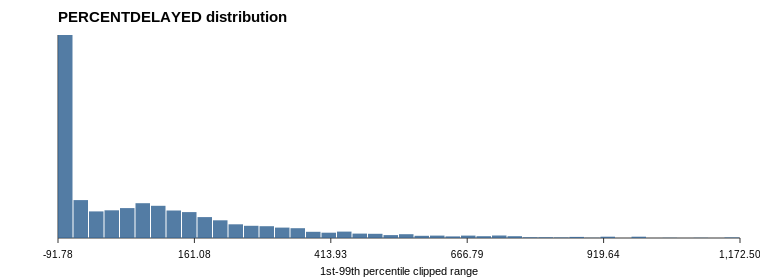

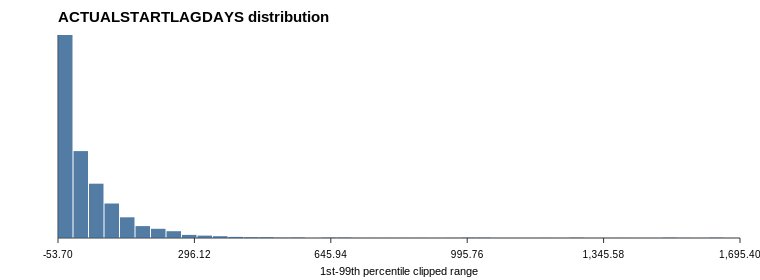

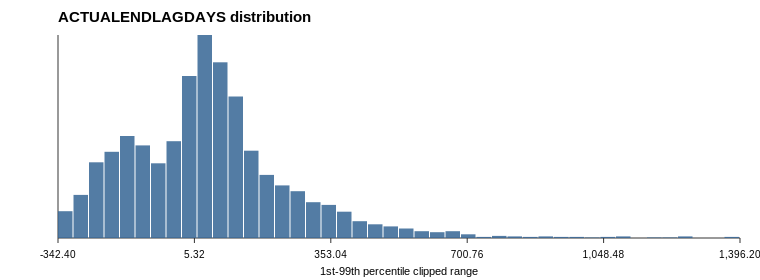

In [5]:
target_summ=[]
for t in TARGETS:
    target_summ.append({'target':t, **pct_summary(num[t])})
display(table(target_summ, ['target','n','mean','std','p0','p1','p5','p10','p25','p50','p75','p90','p95','p99','p100'], 'Target summaries'))
for t in TARGETS:
    display(svg_hist(num[t], f'{t} distribution'))

## Correlation Computation and Predictor Classes
Outcome-derived timing fields are retained in the full correlation output but flagged as leakage. Candidate predictor rankings exclude target columns, actual-duration/payment-span fields, explicit actual dates/posting dates, and dataset diagnostic constants.

In [6]:
leakage=set(TARGETS) | {'ACTUALDURATIONDAYS','PAYMENTSPANDAYS','ACTUALSTARTDATE','ACTUALENDDATE','FIRSTPOSTINGDATE','LASTPOSTINGDATE','PLANNEDSTARTTOFIRSTPAYDAYS','PLANNEDENDTOLASTPAYDAYS'}
diag={'TOTALPROJECTCOUNT','IGNOREDINVALIDSCHEDULEPROJECTCOUNT','IGNOREDINVALIDSCHEDULEPROJECTPCT'}
def cls(c):
    if c in TARGETS: return 'target'
    if c in leakage: return 'outcome/leakage'
    if c in diag: return 'dataset diagnostic'
    if c.startswith('CI_KW_'): return 'keyword: CI.DESCRIPTION'
    if c.startswith('PM_KW_'): return 'keyword: PM.DESCRIPTION'
    if c.startswith('CM_KW_'): return 'keyword: CM.NAME_DESC'
    return 'numeric predictor'

missing=[]
for c,a in num.items():
    finite=np.isfinite(a)
    missing.append({'column':c,'class':cls(c),'missing':int((~finite).sum()),'missing_pct':100*(~finite).sum()/len(a),'unique_values':len(np.unique(a[finite]))})
missing=sorted(missing,key=lambda r:(-r['missing_pct'],r['class'],r['column']))
display(table([{'class':k,'columns':v} for k,v in Counter(cls(c) for c in num).items()], ['class','columns'], 'Column classes'))
display(table(missing, ['column','class','missing','missing_pct','unique_values'], 'Highest numeric missingness', max_rows=30))
write_csv(f'{OUT_PREFIX}_numeric_missingness.csv', missing)

class,columns
numeric predictor,76.00
outcome/leakage,4.0000
target,3.0000
dataset diagnostic,3.0000
keyword: CI.DESCRIPTION,100.00
keyword: PM.DESCRIPTION,100.00
keyword: CM.NAME_DESC,100.00


column,class,missing,missing_pct,unique_values
STDDEVCONTRACTBURN,numeric predictor,"3,296.00",98.95,35.00
GROSSTONETBURNRATIO,numeric predictor,"1,360.00",40.83,27.00
ITEMBURNHERFINDAHL,numeric predictor,"1,360.00",40.83,"1,910.00"
MAXABSITEMSHAREOFPROJECT,numeric predictor,"1,360.00",40.83,"1,910.00"
NEGATIVEBURNABSSHAREOFNET,numeric predictor,"1,360.00",40.83,770.00
STDDEVDAYSBETWEENPAYDATES,numeric predictor,808.00,24.26,"2,354.00"
AVGDAYSBETWEENPAYDATES,numeric predictor,632.00,18.97,"1,832.00"
MAXDAYSBETWEENPAYDATES,numeric predictor,632.00,18.97,343.00
MINDAYSBETWEENPAYDATES,numeric predictor,632.00,18.97,79.00
NUMLONGPAYDATEGAPS,numeric predictor,632.00,18.97,10.00


In [7]:
corr=[]
for target in TARGETS:
    y=num[target]
    for c,x in num.items():
        if c==target: continue
        row={'target':target,'feature':c,'class':cls(c),'is_candidate_predictor':cls(c) not in {'target','outcome/leakage','dataset diagnostic'}}
        for m in ['pearson','spearman','kendall']:
            r,p,n=corr_pair(x,y,m); row[f'{m}_r']=r; row[f'{m}_p']=p; row[f'{m}_n']=n
        row['abs_spearman_r']=abs(row['spearman_r']) if np.isfinite(row['spearman_r']) else np.nan
        row['direction']='positive' if np.isfinite(row['spearman_r']) and row['spearman_r']>0 else ('negative' if np.isfinite(row['spearman_r']) and row['spearman_r']<0 else '')
        corr.append(row)
for target in TARGETS:
    idx=[i for i,r in enumerate(corr) if r['target']==target]
    for m in ['pearson','spearman','kendall']:
        q=bh([corr[i][f'{m}_p'] for i in idx])
        for j,i in enumerate(idx): corr[i][f'{m}_q_bh']=float(q[j]) if np.isfinite(q[j]) else np.nan

corr_cols=['target','feature','class','is_candidate_predictor','pearson_r','pearson_p','pearson_q_bh','pearson_n','spearman_r','spearman_p','spearman_q_bh','spearman_n','kendall_r','kendall_p','kendall_q_bh','kendall_n','abs_spearman_r','direction']
write_csv(f'{OUT_PREFIX}_all_correlations.csv', corr, corr_cols)
primary=sorted([r for r in corr if r['target']=='PERCENTDELAYED'], key=lambda r: (-(r['abs_spearman_r'] if np.isfinite(r['abs_spearman_r']) else -1), r['feature']))
candidates=[r for r in primary if r['is_candidate_predictor']]
write_csv(f'{OUT_PREFIX}_percentdelayed_candidate_correlations.csv', candidates, corr_cols)
display(table(primary, ['feature','class','is_candidate_predictor','pearson_r','spearman_r','kendall_r','spearman_q_bh','spearman_n','direction'], 'Top overall correlations with PERCENTDELAYED, including leakage fields', max_rows=30))
display(table(candidates, ['feature','class','pearson_r','spearman_r','kendall_r','spearman_q_bh','spearman_n','direction'], 'Top candidate predictor correlations with PERCENTDELAYED', max_rows=40))

feature,class,is_candidate_predictor,pearson_r,spearman_r,kendall_r,spearman_q_bh,spearman_n,direction
PAYDATESPERPLANNEDMONTH,numeric predictor,1.0000,0.4437,0.8543,0.6724,0.0000,"3,331.00",positive
ACTUALENDLAGDAYS,target,0.0000,0.0535,0.8006,0.6099,0.0000,"3,331.00",positive
PLANNEDENDTOLASTPAYDAYS,outcome/leakage,0.0000,0.0535,0.8006,0.6099,0.0000,"3,331.00",positive
DOLLARSPERPLANNEDDAY,numeric predictor,1.0000,0.5851,0.7953,0.5908,0.0000,"3,331.00",positive
DOLLARSPERPLANNEDMONTH,numeric predictor,1.0000,0.5851,0.7953,0.5908,0.0000,"3,331.00",positive
SHAREMISSINGORZEROPLANNEDVALUEITEMS,numeric predictor,1.0000,-0.3471,-0.7584,-0.6020,0.0000,"3,331.00",negative
AVGUNITPRICE,numeric predictor,1.0000,-0.0078,0.7510,0.5405,0.0000,"3,331.00",positive
ACTUALDURATIONDAYS,outcome/leakage,0.0000,0.5254,0.7487,0.5671,0.0000,"3,331.00",positive
PAYMENTSPANDAYS,outcome/leakage,0.0000,0.5254,0.7487,0.5671,0.0000,"3,331.00",positive
CI_KW_MOBILIZATION,keyword: CI.DESCRIPTION,1.0000,0.2479,0.7473,0.5850,0.0000,"3,331.00",positive


feature,class,pearson_r,spearman_r,kendall_r,spearman_q_bh,spearman_n,direction
PAYDATESPERPLANNEDMONTH,numeric predictor,0.4437,0.8543,0.6724,0.0000,"3,331.00",positive
DOLLARSPERPLANNEDDAY,numeric predictor,0.5851,0.7953,0.5908,0.0000,"3,331.00",positive
DOLLARSPERPLANNEDMONTH,numeric predictor,0.5851,0.7953,0.5908,0.0000,"3,331.00",positive
SHAREMISSINGORZEROPLANNEDVALUEITEMS,numeric predictor,-0.3471,-0.7584,-0.6020,0.0000,"3,331.00",negative
AVGUNITPRICE,numeric predictor,-0.0078,0.7510,0.5405,0.0000,"3,331.00",positive
CI_KW_MOBILIZATION,keyword: CI.DESCRIPTION,0.2479,0.7473,0.5850,0.0000,"3,331.00",positive
ITEMENDSPREADDAYS,numeric predictor,0.3068,0.7465,0.5637,0.0000,"3,331.00",positive
MAXUNITPRICE,numeric predictor,-0.0029,0.7423,0.5283,0.0000,"3,331.00",positive
STDDEVUNITPRICE,numeric predictor,-0.0029,0.7406,0.5263,0.0000,"3,308.00",positive
MINCONTRACTBURN,numeric predictor,0.0399,0.7306,0.5169,0.0000,"3,331.00",positive


## Positive and Negative Correlates
Positive Spearman correlation means larger predictor values tend to align with greater delay. Negative correlation means larger values tend to align with less delay or earlier completion.

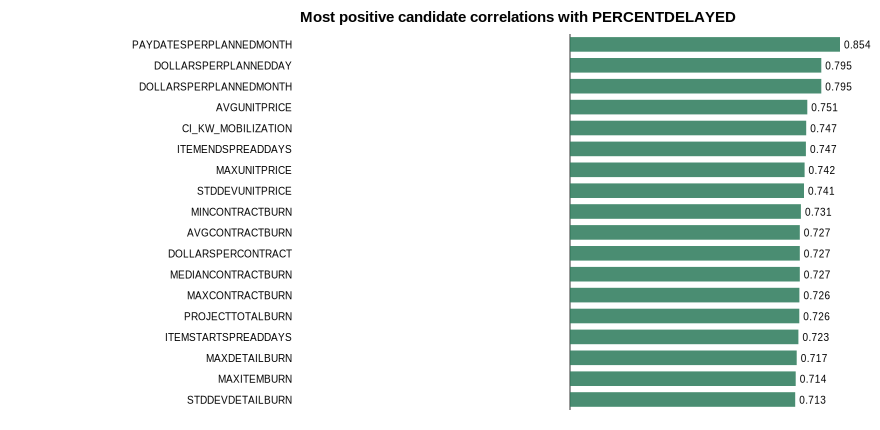

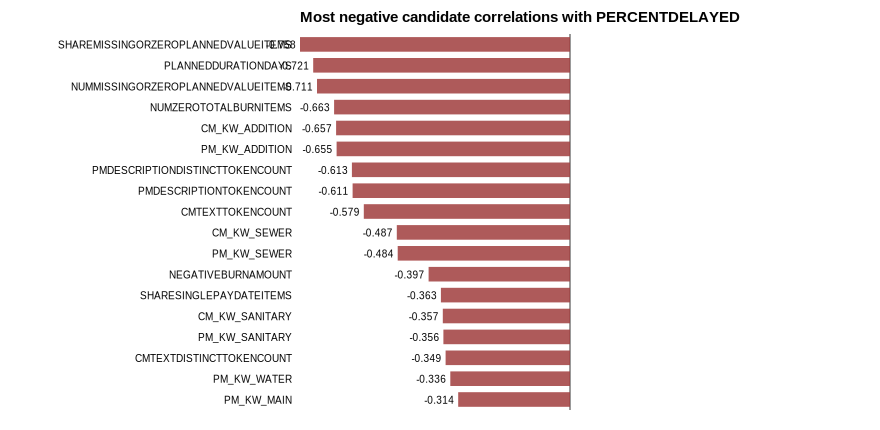

feature,class,pearson_r,spearman_r,kendall_r,spearman_q_bh,spearman_n
PAYDATESPERPLANNEDMONTH,numeric predictor,0.4437,0.8543,0.6724,0.0000,"3,331.00"
DOLLARSPERPLANNEDDAY,numeric predictor,0.5851,0.7953,0.5908,0.0000,"3,331.00"
DOLLARSPERPLANNEDMONTH,numeric predictor,0.5851,0.7953,0.5908,0.0000,"3,331.00"
AVGUNITPRICE,numeric predictor,-0.0078,0.7510,0.5405,0.0000,"3,331.00"
CI_KW_MOBILIZATION,keyword: CI.DESCRIPTION,0.2479,0.7473,0.5850,0.0000,"3,331.00"
ITEMENDSPREADDAYS,numeric predictor,0.3068,0.7465,0.5637,0.0000,"3,331.00"
MAXUNITPRICE,numeric predictor,-0.0029,0.7423,0.5283,0.0000,"3,331.00"
STDDEVUNITPRICE,numeric predictor,-0.0029,0.7406,0.5263,0.0000,"3,308.00"
MINCONTRACTBURN,numeric predictor,0.0399,0.7306,0.5169,0.0000,"3,331.00"
AVGCONTRACTBURN,numeric predictor,0.0398,0.7273,0.5134,0.0000,"3,331.00"


feature,class,pearson_r,spearman_r,kendall_r,spearman_q_bh,spearman_n
SHAREMISSINGORZEROPLANNEDVALUEITEMS,numeric predictor,-0.3471,-0.7584,-0.6020,0.0000,"3,331.00"
PLANNEDDURATIONDAYS,numeric predictor,-0.2287,-0.7212,-0.5323,0.0000,"3,331.00"
NUMMISSINGORZEROPLANNEDVALUEITEMS,numeric predictor,-0.2688,-0.7106,-0.5126,0.0000,"3,331.00"
NUMZEROTOTALBURNITEMS,numeric predictor,-0.2603,-0.6627,-0.4670,0.0000,"3,331.00"
CM_KW_ADDITION,keyword: CM.NAME_DESC,-0.2806,-0.6569,-0.5355,0.0000,"3,331.00"
PM_KW_ADDITION,keyword: PM.DESCRIPTION,-0.2812,-0.6555,-0.5353,0.0000,"3,331.00"
PMDESCRIPTIONDISTINCTTOKENCOUNT,numeric predictor,-0.1445,-0.6126,-0.4280,0.0000,"3,331.00"
PMDESCRIPTIONTOKENCOUNT,numeric predictor,-0.1177,-0.6107,-0.4265,0.0000,"3,331.00"
CMTEXTTOKENCOUNT,numeric predictor,-0.2548,-0.5791,-0.4074,0.0000,"3,331.00"
CM_KW_SEWER,keyword: CM.NAME_DESC,-0.2094,-0.4866,-0.3965,0.0000,"3,331.00"


In [8]:
pos=sorted([r for r in candidates if np.isfinite(r['spearman_r']) and r['spearman_r']>0], key=lambda r:-r['spearman_r'])
neg=sorted([r for r in candidates if np.isfinite(r['spearman_r']) and r['spearman_r']<0], key=lambda r:r['spearman_r'])
display(svg_bar(pos[:18], title='Most positive candidate correlations with PERCENTDELAYED'))
display(svg_bar(neg[:18], title='Most negative candidate correlations with PERCENTDELAYED'))
display(table(pos, ['feature','class','pearson_r','spearman_r','kendall_r','spearman_q_bh','spearman_n'], 'Most positive candidates', max_rows=25))
display(table(neg, ['feature','class','pearson_r','spearman_r','kendall_r','spearman_q_bh','spearman_n'], 'Most negative candidates', max_rows=25))

## Predictor Family Assessment
This shows whether the strongest signals are coming from general numeric project complexity fields or from the three separate keyword sources.

In [9]:
fams=[]
for k in sorted(set(r['class'] for r in candidates)):
    rs=[r for r in candidates if r['class']==k and np.isfinite(r['spearman_r'])]
    if rs:
        vals=[abs(r['spearman_r']) for r in rs]
        fams.append({'class':k,'features':len(rs),'median_abs_spearman':float(np.median(vals)),'p90_abs_spearman':float(np.percentile(vals,90)),'max_abs_spearman':float(np.max(vals)),'positive_features':sum(r['spearman_r']>0 for r in rs),'negative_features':sum(r['spearman_r']<0 for r in rs)})
fams=sorted(fams,key=lambda r:-r['max_abs_spearman'])
display(table(fams, ['class','features','median_abs_spearman','p90_abs_spearman','max_abs_spearman','positive_features','negative_features'], 'Signal strength by predictor family'))
for k in ['numeric predictor','keyword: CI.DESCRIPTION','keyword: PM.DESCRIPTION','keyword: CM.NAME_DESC']:
    rs=sorted([r for r in candidates if r['class']==k and np.isfinite(r['spearman_r'])], key=lambda r:-abs(r['spearman_r']))[:18]
    if rs: display(table(rs, ['feature','pearson_r','spearman_r','kendall_r','spearman_q_bh','spearman_n','direction'], f'Top {k} fields', max_rows=18))

class,features,median_abs_spearman,p90_abs_spearman,max_abs_spearman,positive_features,negative_features
numeric predictor,76.00,0.5772,0.7356,0.8543,62.00,14.00
keyword: CI.DESCRIPTION,100.00,0.3019,0.5231,0.7473,66.00,34.00
keyword: CM.NAME_DESC,100.00,0.0939,0.2023,0.6569,53.00,47.00
keyword: PM.DESCRIPTION,100.00,0.1075,0.2263,0.6555,39.00,61.00


feature,pearson_r,spearman_r,kendall_r,spearman_q_bh,spearman_n,direction
PAYDATESPERPLANNEDMONTH,0.4437,0.8543,0.6724,0.0000,"3,331.00",positive
DOLLARSPERPLANNEDDAY,0.5851,0.7953,0.5908,0.0000,"3,331.00",positive
DOLLARSPERPLANNEDMONTH,0.5851,0.7953,0.5908,0.0000,"3,331.00",positive
SHAREMISSINGORZEROPLANNEDVALUEITEMS,-0.3471,-0.7584,-0.6020,0.0000,"3,331.00",negative
AVGUNITPRICE,-0.0078,0.7510,0.5405,0.0000,"3,331.00",positive
ITEMENDSPREADDAYS,0.3068,0.7465,0.5637,0.0000,"3,331.00",positive
MAXUNITPRICE,-0.0029,0.7423,0.5283,0.0000,"3,331.00",positive
STDDEVUNITPRICE,-0.0029,0.7406,0.5263,0.0000,"3,308.00",positive
MINCONTRACTBURN,0.0399,0.7306,0.5169,0.0000,"3,331.00",positive
AVGCONTRACTBURN,0.0398,0.7273,0.5134,0.0000,"3,331.00",positive


feature,pearson_r,spearman_r,kendall_r,spearman_q_bh,spearman_n,direction
CI_KW_MOBILIZATION,0.2479,0.7473,0.5850,0.0000,"3,331.00",positive
CI_KW_TRAFFIC,0.1515,0.7043,0.5393,0.0000,"3,331.00",positive
CI_KW_CONTROL,0.2283,0.6967,0.5352,0.0000,"3,331.00",positive
CI_KW_BASE,0.1696,0.5827,0.4463,0.0000,"3,331.00",positive
CI_KW_SIGN,0.1648,0.5542,0.4177,0.0000,"3,331.00",positive
CI_KW_PAVEMENT,0.1659,0.5480,0.4178,0.0000,"3,331.00",positive
CI_KW_MARKING,0.1387,0.5420,0.4220,0.0000,"3,331.00",positive
CI_KW_MESSAGE,0.1881,0.5361,0.4193,0.0000,"3,331.00",positive
CI_KW_INFORMATION,0.1960,0.5313,0.4276,0.0000,"3,331.00",positive
CI_KW_PUBLIC,0.1989,0.5303,0.4269,0.0000,"3,331.00",positive


feature,pearson_r,spearman_r,kendall_r,spearman_q_bh,spearman_n,direction
PM_KW_ADDITION,-0.2812,-0.6555,-0.5353,0.0000,"3,331.00",negative
PM_KW_SEWER,-0.2090,-0.4841,-0.3950,0.0000,"3,331.00",negative
PM_KW_SANITARY,-0.1537,-0.3556,-0.2903,0.0000,"3,331.00",negative
PM_KW_WATER,-0.1419,-0.3362,-0.2744,0.0000,"3,331.00",negative
PM_KW_VOLUME,0.1275,0.3246,0.2650,0.0000,"3,331.00",positive
PM_KW_MAIN,-0.1239,-0.3140,-0.2563,0.0000,"3,331.00",negative
PM_KW_HIGH,0.1214,0.3000,0.2449,0.0000,"3,331.00",positive
PM_KW_STORM,-0.1260,-0.2864,-0.2338,0.0000,"3,331.00",negative
PM_KW_PRESERVATION,0.1064,0.2738,0.2236,0.0000,"3,331.00",positive
PM_KW_PAVING,-0.1181,-0.2481,-0.2025,0.0000,"3,331.00",negative


feature,pearson_r,spearman_r,kendall_r,spearman_q_bh,spearman_n,direction
CM_KW_ADDITION,-0.2806,-0.6569,-0.5355,0.0000,"3,331.00",negative
CM_KW_SEWER,-0.2094,-0.4866,-0.3965,0.0000,"3,331.00",negative
CM_KW_SANITARY,-0.1539,-0.3572,-0.2913,0.0000,"3,331.00",negative
CM_KW_WATER,-0.1286,-0.2787,-0.2270,0.0000,"3,331.00",negative
CM_KW_STORM,-0.1230,-0.2747,-0.2242,0.0000,"3,331.00",negative
CM_KW_MAIN,-0.1017,-0.2357,-0.1907,0.0000,"3,331.00",negative
CM_KW_VOLUME,0.0790,0.2299,0.1878,0.0000,"3,331.00",positive
CM_KW_PAVING,-0.1151,-0.2267,-0.1851,0.0000,"3,331.00",negative
CM_KW_ESTATES,-0.0971,-0.2235,-0.1824,0.0000,"3,331.00",negative
CM_KW_HIGH,0.0751,0.2161,0.1763,0.0000,"3,331.00",positive


## Secondary Target Rankings
These tables show whether the same predictors align more strongly with start lag or end lag. This helps interpret whether a delay signal appears to be about late starts, late finishes, or broad schedule stretch.

In [10]:
for target in ['ACTUALSTARTLAGDAYS','ACTUALENDLAGDAYS']:
    rs=sorted([r for r in corr if r['target']==target and r['is_candidate_predictor'] and np.isfinite(r['spearman_r'])], key=lambda r:-abs(r['spearman_r']))[:35]
    display(table(rs, ['feature','class','pearson_r','spearman_r','kendall_r','spearman_q_bh','spearman_n','direction'], f'Top candidate correlations with {target}', max_rows=35))

feature,class,pearson_r,spearman_r,kendall_r,spearman_q_bh,spearman_n,direction
PAYDATESPERPLANNEDMONTH,numeric predictor,0.0420,-0.6560,-0.4762,0.0000,"3,331.00",negative
DOLLARSPERPLANNEDDAY,numeric predictor,0.0221,-0.6141,-0.4457,0.0000,"3,331.00",negative
DOLLARSPERPLANNEDMONTH,numeric predictor,0.0221,-0.6141,-0.4457,0.0000,"3,331.00",negative
STDDEVUNITPRICE,numeric predictor,-0.0037,-0.5991,-0.4298,0.0000,"3,308.00",negative
MAXUNITPRICE,numeric predictor,-0.0034,-0.5889,-0.4218,0.0000,"3,331.00",negative
AVGUNITPRICE,numeric predictor,-0.0041,-0.5814,-0.4095,0.0000,"3,331.00",negative
MINCONTRACTBURN,numeric predictor,0.0027,-0.5748,-0.4134,0.0000,"3,331.00",negative
DOLLARSPERCONTRACT,numeric predictor,0.0027,-0.5716,-0.4114,0.0000,"3,331.00",negative
AVGCONTRACTBURN,numeric predictor,0.0027,-0.5716,-0.4114,0.0000,"3,331.00",negative
MEDIANCONTRACTBURN,numeric predictor,0.0027,-0.5715,-0.4114,0.0000,"3,331.00",negative


feature,class,pearson_r,spearman_r,kendall_r,spearman_q_bh,spearman_n,direction
ITEMENDSPREADDAYS,numeric predictor,0.0543,0.7464,0.5891,0.0000,"3,331.00",positive
ITEMSTARTSPREADDAYS,numeric predictor,0.0293,0.7294,0.5628,0.0000,"3,331.00",positive
MAXITEMPAYMENTSPANDAYS,numeric predictor,0.0331,0.7274,0.5594,0.0000,"3,331.00",positive
PAYESTIMATECOUNT,numeric predictor,0.0595,0.7267,0.5666,0.0000,"3,331.00",positive
MAXDAYSBETWEENPAYDATES,numeric predictor,0.0050,0.7151,0.5394,0.0000,"2,699.00",positive
DOLLARSPERCONTRACT,numeric predictor,0.0176,0.7070,0.5314,0.0000,"3,331.00",positive
AVGCONTRACTBURN,numeric predictor,0.0176,0.7070,0.5314,0.0000,"3,331.00",positive
MEDIANCONTRACTBURN,numeric predictor,0.0176,0.7070,0.5314,0.0000,"3,331.00",positive
MINCONTRACTBURN,numeric predictor,0.0177,0.7070,0.5315,0.0000,"3,331.00",positive
MAXCONTRACTBURN,numeric predictor,0.0176,0.7067,0.5311,0.0000,"3,331.00",positive


## Deep Dives for Best Performers
For selected top positive and negative candidates, the plots show binned median `PERCENTDELAYED` with interquartile range. This sanity-checks whether the association is broadly monotonic or driven by a narrow artifact.

feature,class,spearman_r,n,coverage_projects,coverage_pct,median_delay_present,median_delay_absent,median_present_minus_absent
PAYDATESPERPLANNEDMONTH,numeric predictor,0.8543,"3,331.00",,,217.99,-88.20,306.19
DOLLARSPERPLANNEDDAY,numeric predictor,0.7953,"3,331.00",,,180.39,-83.41,263.80
DOLLARSPERPLANNEDMONTH,numeric predictor,0.7953,"3,331.00",,,180.39,-83.41,263.80
AVGUNITPRICE,numeric predictor,0.7510,"3,331.00",,,152.66,-83.43,236.09
CI_KW_MOBILIZATION,keyword: CI.DESCRIPTION,0.7473,"3,331.00","1,839.00",55.21,148.34,-81.56,229.91
ITEMENDSPREADDAYS,numeric predictor,0.7465,"3,331.00",,,193.56,-87.80,281.36
MAXUNITPRICE,numeric predictor,0.7423,"3,331.00",,,148.20,-83.43,231.62
SHAREMISSINGORZEROPLANNEDVALUEITEMS,numeric predictor,-0.7584,"3,331.00",,,-83.43,139.50,-222.92
PLANNEDDURATIONDAYS,numeric predictor,-0.7212,"3,331.00",,,-85.69,222.73,-308.41
NUMMISSINGORZEROPLANNEDVALUEITEMS,numeric predictor,-0.7106,"3,331.00",,,-82.92,139.50,-222.41


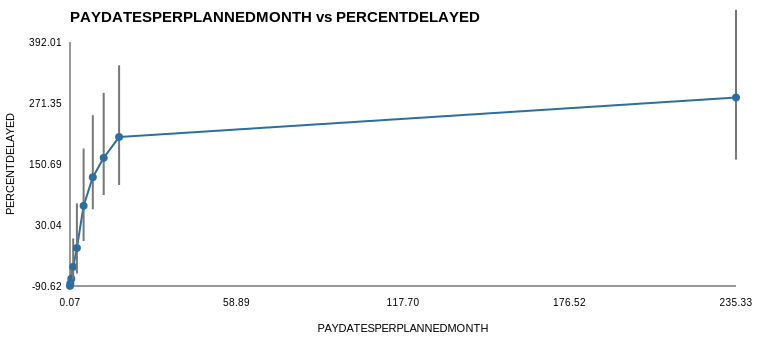

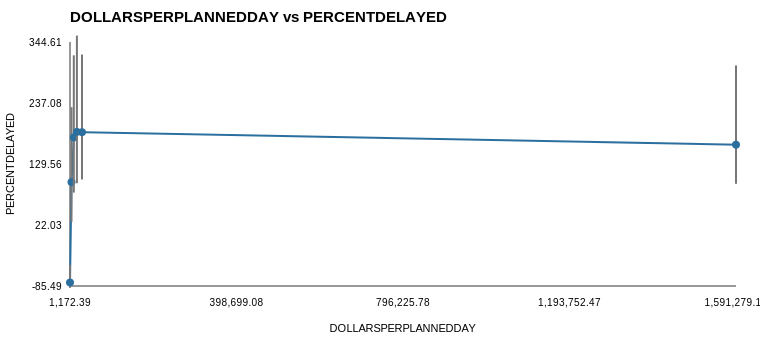

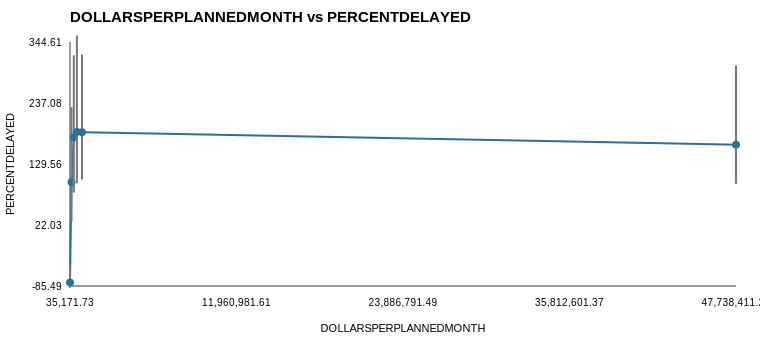

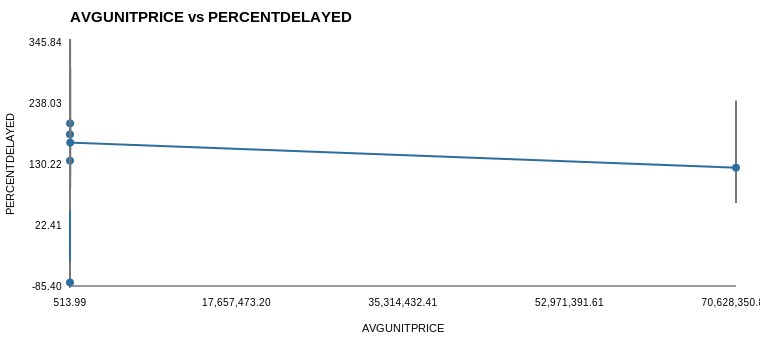

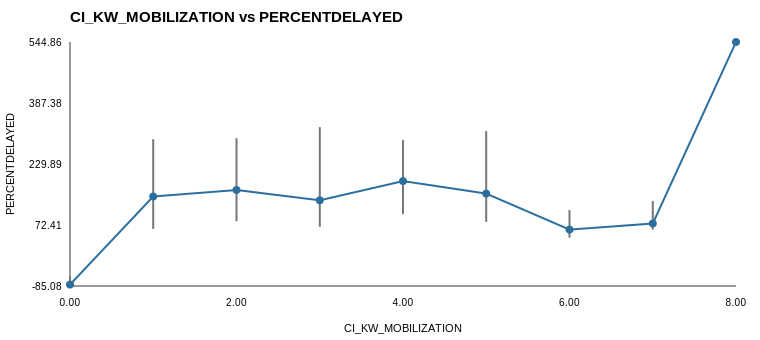

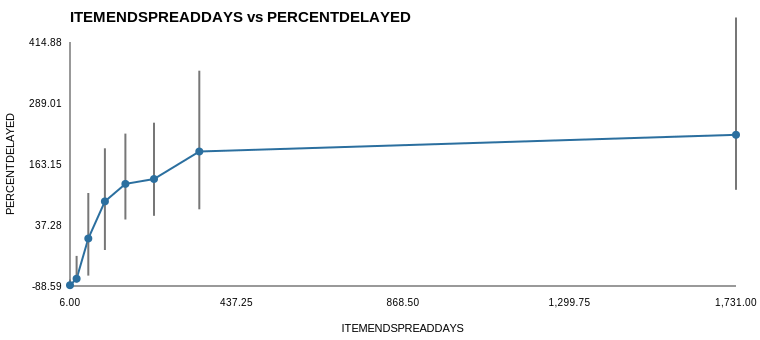

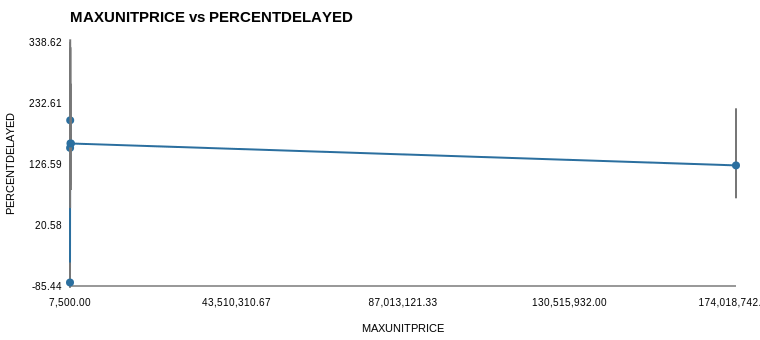

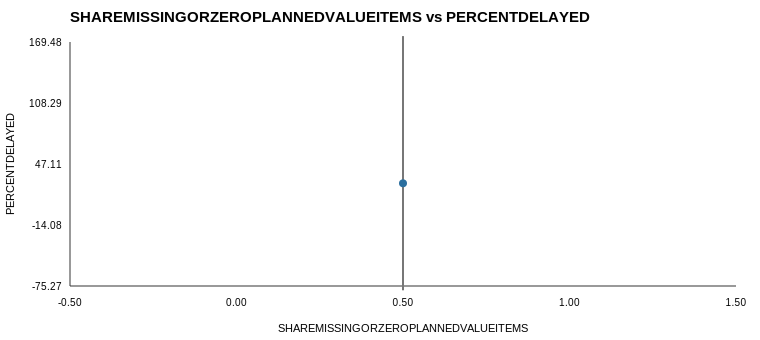

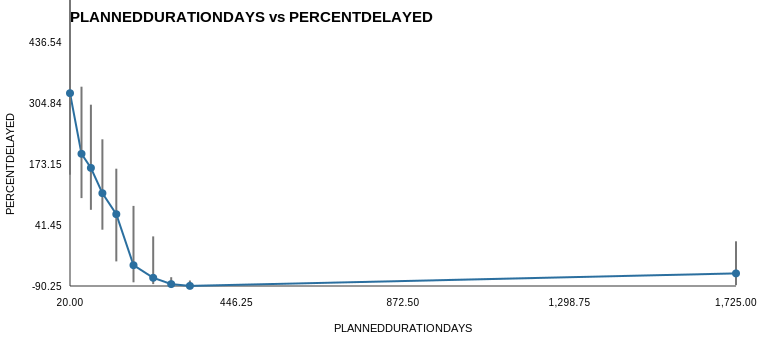

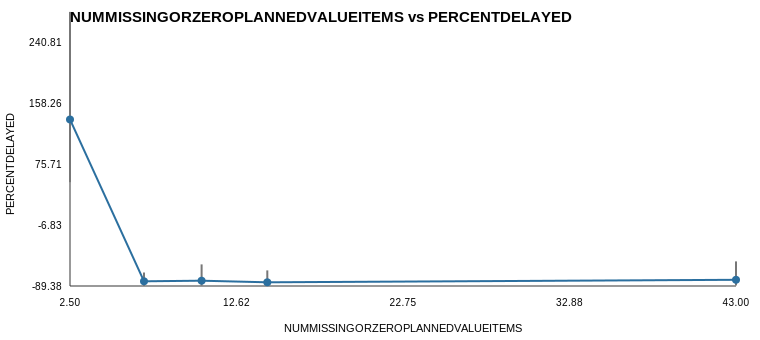

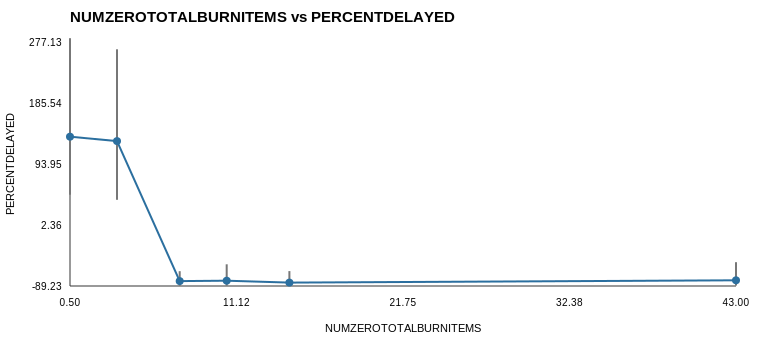

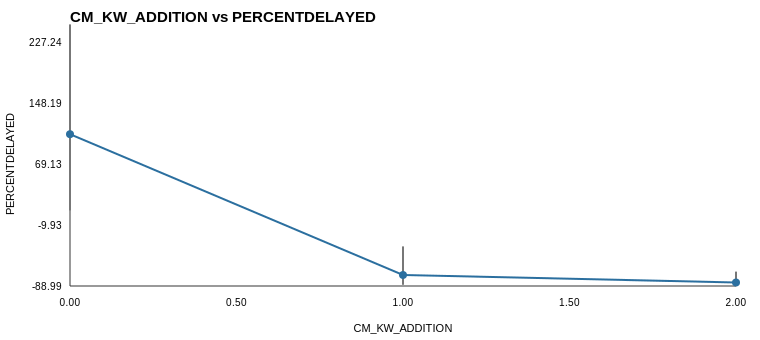

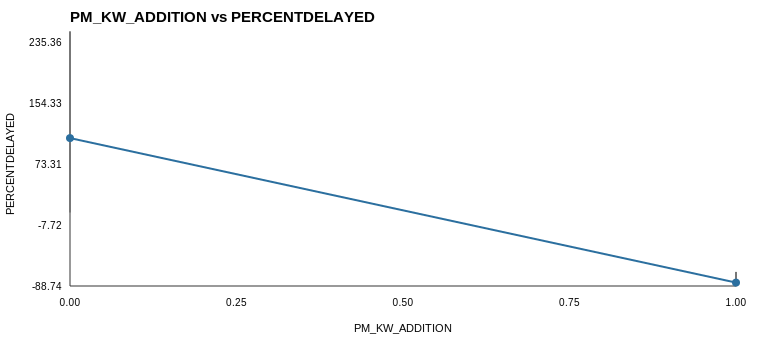

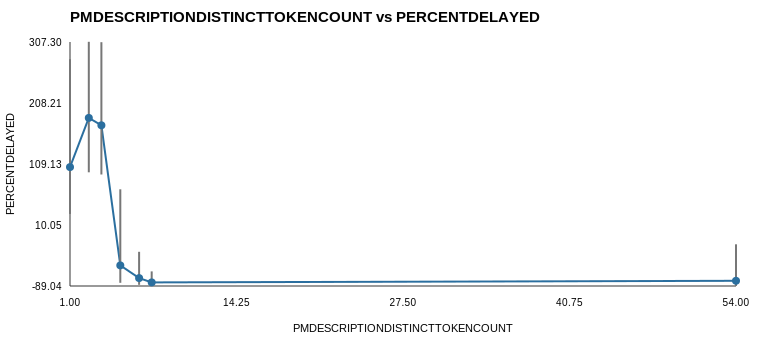

In [11]:
selected=[]
for pool in [pos[:7], neg[:7], candidates[:12]]:
    for r in pool:
        if r['feature'] not in [x['feature'] for x in selected]: selected.append(r)
selected=selected[:16]
y=num['PERCENTDELAYED']
deep=[]
for r in selected:
    f=r['feature']; x=num[f]; m=np.isfinite(x)&np.isfinite(y); xv=x[m]; yv=y[m]
    if f in kw_cols:
        pres=xv>0; present=pres.sum(); absent=(~pres).sum()
        deep.append({'feature':f,'class':r['class'],'spearman_r':r['spearman_r'],'n':int(m.sum()),'coverage_projects':int(present),'coverage_pct':100*present/len(pres) if len(pres) else np.nan,'median_delay_present':float(np.median(yv[pres])) if present else np.nan,'median_delay_absent':float(np.median(yv[~pres])) if absent else np.nan,'median_present_minus_absent':float(np.median(yv[pres])-np.median(yv[~pres])) if present and absent else np.nan})
    else:
        hi=xv>=np.percentile(xv,75); lo=xv<=np.percentile(xv,25)
        deep.append({'feature':f,'class':r['class'],'spearman_r':r['spearman_r'],'n':int(m.sum()),'coverage_projects':'','coverage_pct':'','median_delay_present':float(np.median(yv[hi])),'median_delay_absent':float(np.median(yv[lo])),'median_present_minus_absent':float(np.median(yv[hi])-np.median(yv[lo]))})
write_csv(f'{OUT_PREFIX}_deep_dive_summary.csv', deep)
display(table(deep, ['feature','class','spearman_r','n','coverage_projects','coverage_pct','median_delay_present','median_delay_absent','median_present_minus_absent'], 'Deep-dive summary', max_rows=20))
for r in selected[:14]:
    display(svg_binned(num[r['feature']], y, f'{r["feature"]} vs PERCENTDELAYED', r['feature']))

## Keyword Sanity Checks
Keyword features are sparse count predictors. This table shows how often each top keyword appears and how median delay differs when the keyword is present versus absent.

In [12]:
kwcorr=sorted([r for r in candidates if r['feature'] in kw_cols and np.isfinite(r['spearman_r'])], key=lambda r:-abs(r['spearman_r']))[:50]
kwrows=[]; y=num['PERCENTDELAYED']
for r in kwcorr:
    f=r['feature']; x=num[f]; m=np.isfinite(x)&np.isfinite(y); pres=x[m]>0; yy=y[m]
    kwrows.append({'feature':f,'source':r['class'],'spearman_r':r['spearman_r'],'coverage_projects':int(pres.sum()),'coverage_pct':100*pres.mean() if len(pres) else np.nan,'median_delay_present':float(np.median(yy[pres])) if pres.sum() else np.nan,'median_delay_absent':float(np.median(yy[~pres])) if (~pres).sum() else np.nan,'mean_count_when_present':float(np.mean(x[m][pres])) if pres.sum() else np.nan})
write_csv(f'{OUT_PREFIX}_keyword_correlation_sanity.csv', kwrows)
display(table(kwrows, ['feature','source','spearman_r','coverage_projects','coverage_pct','median_delay_present','median_delay_absent','mean_count_when_present'], 'Top keyword correlation sanity checks', max_rows=50))

feature,source,spearman_r,coverage_projects,coverage_pct,median_delay_present,median_delay_absent,mean_count_when_present
CI_KW_MOBILIZATION,keyword: CI.DESCRIPTION,0.7473,"1,839.00",55.21,148.34,-81.56,1.3225
CI_KW_TRAFFIC,keyword: CI.DESCRIPTION,0.7043,"1,894.00",56.86,142.35,-81.28,2.0723
CI_KW_CONTROL,keyword: CI.DESCRIPTION,0.6967,"1,875.00",56.29,143.12,-81.16,1.5781
CM_KW_ADDITION,keyword: CM.NAME_DESC,-0.6569,"1,038.00",31.16,-84.21,107.77,1.9750
PM_KW_ADDITION,keyword: PM.DESCRIPTION,-0.6555,"1,036.00",31.10,-84.21,107.69,1.0000
CI_KW_BASE,keyword: CI.DESCRIPTION,0.5827,"1,252.00",37.59,161.08,-68.75,2.3466
CI_KW_SIGN,keyword: CI.DESCRIPTION,0.5542,"1,228.00",36.87,158.78,-65.66,8.9275
CI_KW_PAVEMENT,keyword: CI.DESCRIPTION,0.5480,"1,249.00",37.50,154.48,-65.10,4.3891
CI_KW_MARKING,keyword: CI.DESCRIPTION,0.5420,"1,011.00",30.35,179.33,-60.00,1.9960
CI_KW_MESSAGE,keyword: CI.DESCRIPTION,0.5361,926.00,27.80,185.40,-55.87,2.3132


## Top-Predictor Redundancy
Top predictors often describe the same underlying project property. The heatmap below shows Spearman correlations among the highest-ranked candidate predictors.

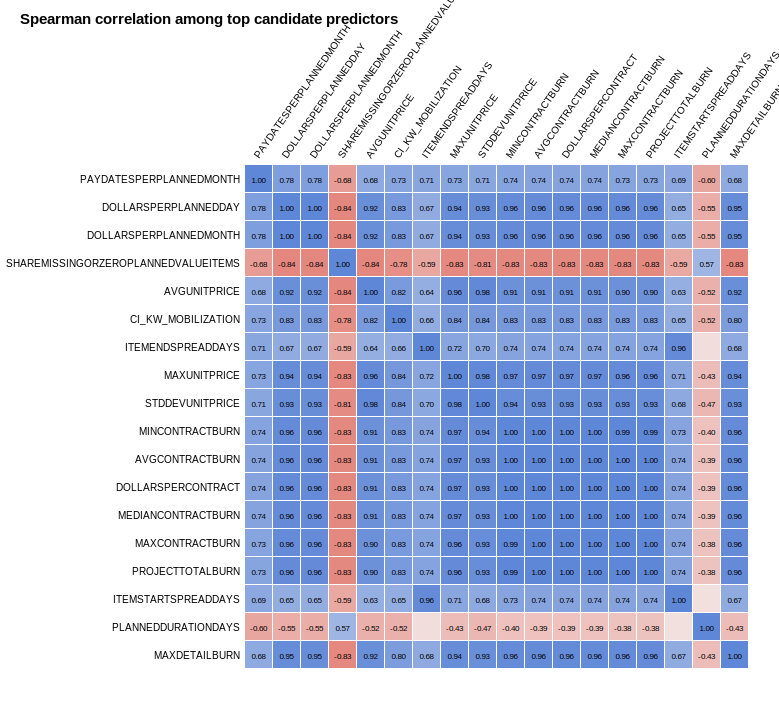

In [13]:
top=[]
for r in candidates:
    if np.isfinite(r['spearman_r']) and r['feature'] not in top: top.append(r['feature'])
    if len(top)>=18: break
cell=28; ml=245; mt=165; width=ml+cell*len(top)+30; height=mt+cell*len(top)+35
parts=[]
for i,f in enumerate(top):
    parts.append(f'<text x="{ml-5}" y="{mt+i*cell+18}" text-anchor="end" font-size="10">{esc(f[:36])}</text>')
    parts.append(f'<text x="{ml+i*cell+14}" y="{mt-6}" text-anchor="start" font-size="10" transform="rotate(-55 {ml+i*cell+14},{mt-6})">{esc(f[:30])}</text>')
for i,f1 in enumerate(top):
    for j,f2 in enumerate(top):
        r,_,_=corr_pair(num[f1],num[f2],'spearman')
        if not np.isfinite(r): col='#eee'
        else:
            a=min(abs(r),1)
            col=f'rgb({int(245-150*a)},{int(245-110*a)},{int(245-30*a)})' if r>=0 else f'rgb({int(245-20*a)},{int(245-130*a)},{int(245-140*a)})'
        parts.append(f'<rect x="{ml+j*cell}" y="{mt+i*cell}" width="{cell-1}" height="{cell-1}" fill="{col}"/>')
        if np.isfinite(r) and abs(r)>=0.35:
            parts.append(f'<text x="{ml+j*cell+14}" y="{mt+i*cell+18}" text-anchor="middle" font-size="8">{r:.2f}</text>')
body=''.join(parts)
display(SVG(f'<svg width="{width}" height="{height}" xmlns="http://www.w3.org/2000/svg"><style>text{{font-family:Arial,sans-serif}}</style><text x="20" y="24" font-size="15" font-weight="600">Spearman correlation among top candidate predictors</text>{body}</svg>'))

## Data-Driven Summary
This section is generated directly from the computed rankings. It is a correlation screen, not a causal model.

In [14]:
summary=[]
summary.append(f'The corrected dataset contains {len(rows):,} project rows, {len(cols):,} columns, and {len(kw_cols):,} keyword predictor columns.')
if candidates:
    b=candidates[0]; summary.append(f'Strongest candidate Spearman correlation with PERCENTDELAYED: {b["feature"]} ({b["class"]}), rho={b["spearman_r"]:.3f}.')
if pos:
    b=pos[0]; summary.append(f'Strongest positive candidate: {b["feature"]}, rho={b["spearman_r"]:.3f}.')
if neg:
    b=neg[0]; summary.append(f'Strongest negative candidate: {b["feature"]}, rho={b["spearman_r"]:.3f}.')
kwtop=[r for r in candidates if r['feature'] in kw_cols]
if kwtop:
    b=kwtop[0]; summary.append(f'Strongest keyword candidate: {b["feature"]} ({b["class"]}), rho={b["spearman_r"]:.3f}.')
summary.append('Fields derived from actual payment timing are flagged as leakage: useful for retrospective explanation, but not valid as forward-looking predictors.')
summary.append('Next step: rerun the same correlation screen within customer or customer/type strata to see whether pooled correlations are dominated by customer mix.')
display(HTML('<ul>'+''.join(f'<li>{esc(s)}</li>' for s in summary)+'</ul>'))
with open(f'{OUT_PREFIX}_summary.md','w',encoding='utf-8') as f:
    f.write('# Project Delay Correlation Analysis Summary\n\n')
    for s in summary: f.write(f'- {s}\n')